In [ ]:
#@title 1 · Setup, seeds and configuration
!pip -q install kagglehub statsmodels

import os, sys, json, math, random, hashlib, time, gc
import numpy as np

CFG = dict(
    KAGGLE_ID  = "alik05/forest-fire-dataset",
    IMG        = 224,
    SEED       = 42,
    VAL_FRAC   = 0.20,
    AUG_COPIES = 4,        # augmented copies per training image (0 = no augmentation)
    EPOCHS     = 100,
    BATCH      = 32,
    PATIENCE   = 15,
    N_SEEDS    = 5,        # repeats per model -> mean +/- SD
    EXTRACT_BS = 16,       # feature-extraction batch; auto-halves on GPU OOM
    HUE        = 0.10,
    L2         = 0.01,
    DROPOUT    = 0.5,
    LR         = 1e-4,
    WD         = 1e-4,
)

# ---- reproducibility -------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(CFG["SEED"])
random.seed(CFG["SEED"]); np.random.seed(CFG["SEED"])
import tensorflow as tf


for _g in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_g, True)
    except Exception as _e:
        print("memory-growth setting skipped:", _e)

tf.keras.utils.set_random_seed(CFG["SEED"])

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", gpus or "NONE  <-- switch runtime to T4 GPU")


import shutil
SUBS   = ("features", "results", "figures", "models")
WORK   = "/content/MWAMNet_revision"
MIRROR = None

for sub in SUBS:
    os.makedirs(os.path.join(WORK, sub), exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive")
    cand = "/content/drive/MyDrive/MWAMNet_revision"
    for sub in SUBS:
        os.makedirs(os.path.join(cand, sub), exist_ok=True)
    if all(os.path.isdir(os.path.join(cand, s)) for s in SUBS):
        MIRROR = cand
    else:
        print("Drive mounted but not writable - local only.")
except Exception as e:
    print("Drive unavailable (%s) - local only." % e)

OUT = WORK

def backup():

    if not MIRROR:
        return
    n = 0
    for sub in SUBS:
        src, dst = os.path.join(WORK, sub), os.path.join(MIRROR, sub)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            a, b = os.path.join(src, f), os.path.join(dst, f)
            if not os.path.exists(b) or os.path.getmtime(a) > os.path.getmtime(b) + 1:
                try:
                    shutil.copy2(a, b); n += 1
                except Exception as e:
                    print("   backup failed for %s (%s)" % (f, e))
    print("   backed up %d file(s) to Drive" % n)

def restore():

    if not MIRROR:
        return
    n = 0
    for sub in SUBS:
        src, dst = os.path.join(MIRROR, sub), os.path.join(WORK, sub)
        if not os.path.isdir(src):
            continue
        for f in os.listdir(src):
            a, b = os.path.join(src, f), os.path.join(dst, f)
            if not os.path.exists(b):
                shutil.copy2(a, b); n += 1
    if n:
        print("Restored %d cached file(s) from Drive - finished stages will be skipped." % n)

restore()
print("Working in :", WORK)
print("Mirrored to:", MIRROR or "nothing - DOWNLOAD")

json.dump(CFG, open(os.path.join(WORK, "config.json"), "w"), indent=2)

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive
Restored 2 cached file(s) from Drive - finished stages will be skipped.
Working in : /content/MWAMNet_revision
Mirrored to: /content/drive/MyDrive/MWAMNet_revision


## 2 · The canonical split

One dataset copy, one stratified split, one seed — for every model.

* `Training/fire` + `Training/nofire` = **1,520** images → 1,216 train / 304 validation
* `Testing/` = **380** images, labels read from the filename prefix, **never touched during training**

The dataset check found 1,900 unique files and zero duplicates, so there is no
train/test leakage.

In [ ]:
#@title 2 · Download, load, and build the split
import kagglehub, glob
from PIL import Image
from sklearn.model_selection import train_test_split

root = kagglehub.dataset_download(CFG["KAGGLE_ID"])
base = glob.glob(os.path.join(root, "**", "Forest Fire Dataset"), recursive=True)[0]
TRAIN_DIR, TEST_DIR = os.path.join(base, "Training"), os.path.join(base, "Testing")

S = CFG["IMG"]

def load(paths):
    # Load images as uint8 [0,255] RGB at S x S -> 286 MB for the whole dataset.
    a = np.zeros((len(paths), S, S, 3), dtype=np.uint8)
    for i, p in enumerate(paths):
        with Image.open(p) as im:
            a[i] = np.asarray(im.convert("RGB").resize((S, S), Image.BILINEAR))
    return a

# --- training pool: label from the class folder ---
pool_paths, pool_y = [], []
for cls, lab in (("nofire", 0), ("fire", 1)):
    fs = sorted(glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg")))
    pool_paths += fs; pool_y += [lab] * len(fs)
pool_y = np.array(pool_y, dtype=np.int32)

# --- held-out test set: label from the filename prefix ---
test_paths = sorted(glob.glob(os.path.join(TEST_DIR, "*.jpg")))
test_y = np.array([0 if os.path.basename(p).lower().startswith("nofire") else 1
                   for p in test_paths], dtype=np.int32)

tr_p, va_p, tr_y, va_y = train_test_split(
    pool_paths, pool_y, test_size=CFG["VAL_FRAC"],
    random_state=CFG["SEED"], stratify=pool_y)

X_tr, X_va, X_te = load(tr_p), load(va_p), load(test_paths)
y_tr, y_va, y_te = tr_y, va_y, test_y

def dist(y): return "nofire=%d fire=%d" % ((y == 0).sum(), (y == 1).sum())
print("train %4d  %s" % (len(y_tr), dist(y_tr)))
print("val   %4d  %s" % (len(y_va), dist(y_va)))
print("TEST  %4d  %s   <- held out, never seen in training" % (len(y_te), dist(y_te)))

np.save(os.path.join(OUT, "results", "y_test.npy"), y_te)
json.dump({"train": tr_p, "val": va_p, "test": test_paths},
          open(os.path.join(OUT, "results", "split_manifest.json"), "w"))
print("\nSplit manifest saved - this is the Table 1 you will report.")

100%|██████████| 142M/142M [00:01<00:00, 85.1MB/s]

Extracting files...


train 1216  nofire=608 fire=608
val    304  nofire=152 fire=152
TEST   380  nofire=190 fire=190   <- held out, never seen in training

Split manifest saved - this is the Table 1 you will report.


In [ ]:
#@title 3 · Feature extraction  (Cached)
from tensorflow.keras.applications import (densenet, mobilenet_v3, resnet50,
                                           vgg16, inception_v3)
from tensorflow.keras.applications import (DenseNet201, MobileNetV3Large,
                                           ResNet50, VGG16, InceptionV3)

BACKBONES = {
    "DenseNet201":      (DenseNet201,      densenet.preprocess_input),
    "MobileNetV3Large": (MobileNetV3Large, mobilenet_v3.preprocess_input),
    "ResNet50":         (ResNet50,         resnet50.preprocess_input),
    "VGG16":            (VGG16,            vgg16.preprocess_input),
    "InceptionV3":      (InceptionV3,      inception_v3.preprocess_input),
}

# ---- deterministic augmentation, generated ONCE and shared by every backbone ----
USE_JPEG = True

def aug_one(img01, seed):
    im = tf.image.stateless_random_flip_left_right(img01, seed)
    im = tf.image.stateless_random_brightness(im, 0.10,     seed + 1)
    im = tf.image.stateless_random_contrast(im, 0.9, 1.1,   seed + 2)
    im = tf.image.stateless_random_saturation(im, 0.9, 1.1, seed + 3)
    im = tf.image.stateless_random_hue(im, CFG["HUE"],      seed + 4)
    im = tf.clip_by_value(im, 0.0, 1.0)
    if USE_JPEG:
        im = tf.image.stateless_random_jpeg_quality(im, 75, 100, seed + 5)
    return tf.cast(tf.round(im * 255.0), tf.uint8)

def build_augmented(X):

    blocks = [X]
    with tf.device("/CPU:0"):
        for c in range(1, CFG["AUG_COPIES"] + 1):
            o = np.empty_like(X)
            for i in range(len(X)):
                s = tf.constant([i, c * 7919 + 13], dtype=tf.int32)
                o[i] = aug_one(tf.cast(X[i], tf.float32) / 255.0, s).numpy()
            blocks.append(o)
            print("   augmented copy %d/%d" % (c, CFG["AUG_COPIES"]))
    out = np.concatenate(blocks)
    del blocks; gc.collect()
    return out

FEAT  = os.path.join(OUT, "features")
todo  = [b for b in BACKBONES if not os.path.exists(os.path.join(FEAT, b + "_test.npy"))]
print("to extract:", todo or "nothing - all cached")

if todo:
    try:
        aug_one(tf.zeros((S, S, 3)), tf.constant([1, 1], tf.int32))
    except Exception as e:
        USE_JPEG = False
        print("JPEG-quality augmentation unavailable (%s) - continuing without it." % type(e).__name__)
    t0 = time.time()
    X_tr_all = build_augmented(X_tr) if CFG["AUG_COPIES"] else X_tr
    print("augmented training pool: %d images  (%.1f min)"
          % (len(X_tr_all), (time.time() - t0) / 60))

def extract(net, prep, u8, bs=None):

    bs  = bs or CFG["EXTRACT_BS"]
    out = np.empty((len(u8), net.output_shape[-1]), dtype=np.float32)
    i   = 0
    while i < len(u8):
        try:
            b = tf.cast(u8[i:i + bs], tf.float32)
            out[i:i + int(b.shape[0])] = net(prep(b), training=False).numpy()
            i += bs
        except tf.errors.ResourceExhaustedError:
            if bs == 1:
                raise
            bs = max(1, bs // 2)
            gc.collect()
            print("   GPU out of memory - retrying at batch size %d" % bs)
    return out

for name in todo:
    t0 = time.time()
    Base, prep = BACKBONES[name]
    net = Base(weights="imagenet", include_top=False,
               input_shape=(S, S, 3), pooling="avg")
    net.trainable = False
    tag = os.path.join(FEAT, name)
    np.save(tag + "_train.npy", extract(net, prep, X_tr_all))
    np.save(tag + "_val.npy",   extract(net, prep, X_va))
    np.save(tag + "_test.npy",  extract(net, prep, X_te))
    dim = np.load(tag + "_test.npy", mmap_mode="r").shape[1]
    del net
    tf.keras.backend.clear_session(); gc.collect()
    print("%-18s dim=%-5d  %.1f min" % (name, dim, (time.time() - t0) / 60))

if todo:
    del X_tr_all
    gc.collect()

N_TR     = len(y_tr)
y_tr_aug = np.tile(y_tr, CFG["AUG_COPIES"] + 1)
np.save(os.path.join(OUT, "results", "y_train_aug.npy"), y_tr_aug)
np.save(os.path.join(OUT, "results", "y_val.npy"), y_va)
backup()
print("\nCached. Everything below runs in seconds.")

to extract: ['DenseNet201', 'MobileNetV3Large', 'ResNet50', 'VGG16', 'InceptionV3']
   augmented copy 1/4
   augmented copy 2/4
   augmented copy 3/4
   augmented copy 4/4
augmented training pool: 6080 images  (1.1 min)
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet201        dim=1920   5.8 min
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3Large   dim=960    1.4 min
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50           dim=2048   1.8 min
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16              dim=512    0.8 min
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
InceptionV3        dim=2048   2.3 min
   backed up 19 file(s) to Drive

Cached. Everything below runs in seconds.


In [ ]:
#@title 4 · Head architecture and training routine
from tensorflow.keras.layers import (Input, Dense, BatchNormalization,
                                     Dropout, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2 as L2reg
from tensorflow.keras.callbacks import EarlyStopping

MODELS = {
    "MWAMNet":          ["DenseNet201", "MobileNetV3Large"],
    "DenseNet201":      ["DenseNet201"],
    "MobileNetV3Large": ["MobileNetV3Large"],
    "ResNet50":         ["ResNet50"],
    "VGG16":            ["VGG16"],
    "InceptionV3":      ["InceptionV3"],
}

def load_feats(backbones, split):
    return [np.load(os.path.join(OUT, "features", "%s_%s.npy" % (b, split)))
            for b in backbones]

def build_head(dims, l2v, drop, units=(1024, 512)):
    ins = [Input(shape=(d,)) for d in dims]
    br  = [Dropout(drop)(BatchNormalization()(i)) for i in ins]
    x   = Concatenate()(br) if len(br) > 1 else br[0]
    for u in units:
        x = Dense(u, activation="relu", kernel_regularizer=L2reg(l2v))(x)
        x = BatchNormalization()(x)
        x = Dropout(drop)(x)
    return Model(ins, Dense(1, activation="sigmoid")(x))

def run(backbones, seed, augment=True, l2v=None, drop=None,
        cosine=True, epochs=None, units=(1024, 512), verbose=0):

    l2v  = CFG["L2"]      if l2v   is None else l2v
    drop = CFG["DROPOUT"] if drop  is None else drop
    ep   = CFG["EPOCHS"]  if epochs is None else epochs
    tf.keras.utils.set_random_seed(seed)

    Xtr = load_feats(backbones, "train")
    ytr = y_tr_aug
    if not augment:
        Xtr = [f[:N_TR] for f in Xtr]; ytr = y_tr
    Xva, Xte = load_feats(backbones, "val"), load_feats(backbones, "test")

    steps = math.ceil(len(ytr) / CFG["BATCH"]) * ep
    lr = (tf.keras.optimizers.schedules.CosineDecay(CFG["LR"], steps, alpha=1e-6)
          if cosine else CFG["LR"])
    m = build_head([f.shape[1] for f in Xtr], l2v, drop, units)
    m.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr,
                                                  weight_decay=CFG["WD"]),
              loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(Xtr, ytr, validation_data=(Xva, y_va),
          epochs=ep, batch_size=CFG["BATCH"], verbose=verbose,
          callbacks=[EarlyStopping(monitor="val_accuracy", mode="max",
                                   patience=CFG["PATIENCE"],
                                   restore_best_weights=True)])
    return m.predict(Xte, verbose=0).ravel(), m

print("Head ready. MWAMNet input dim =",
      sum(f.shape[1] for f in load_feats(MODELS["MWAMNet"], "test")))

Head ready. MWAMNet input dim = 2880


In [ ]:
#@title 5 · Train all six models
probs_all, rows = {}, []

for mname, bbs in MODELS.items():
    ps = []
    for s in range(CFG["N_SEEDS"]):
        p, _ = run(bbs, seed=CFG["SEED"] + s)
        ps.append(p)
        acc = ((p > 0.5).astype(int) == y_te).mean()
        rows.append(dict(model=mname, seed=CFG["SEED"] + s, accuracy=acc))
        print("%-18s seed %2d   test acc = %.4f" % (mname, CFG["SEED"] + s, acc))
    probs_all[mname] = np.stack(ps)
    np.save(os.path.join(OUT, "results", "%s_probs.npy" % mname), probs_all[mname])
    print("-" * 52)

import pandas as pd
pd.DataFrame(rows).to_csv(os.path.join(OUT, "results", "per_seed.csv"), index=False)
backup()
print("Saved per-seed accuracies and per-image probabilities.")

MWAMNet            seed 42   test acc = 0.9921
MWAMNet            seed 43   test acc = 0.9816
MWAMNet            seed 44   test acc = 0.9868
MWAMNet            seed 45   test acc = 0.9895
MWAMNet            seed 46   test acc = 0.9895
----------------------------------------------------
DenseNet201        seed 42   test acc = 0.9895
DenseNet201        seed 43   test acc = 0.9842
DenseNet201        seed 44   test acc = 0.9895
DenseNet201        seed 45   test acc = 0.9789
DenseNet201        seed 46   test acc = 0.9842
----------------------------------------------------
MobileNetV3Large   seed 42   test acc = 0.9737
MobileNetV3Large   seed 43   test acc = 0.9658
MobileNetV3Large   seed 44   test acc = 0.9868
MobileNetV3Large   seed 45   test acc = 0.9842
MobileNetV3Large   seed 46   test acc = 0.9895
----------------------------------------------------
ResNet50           seed 42   test acc = 0.9921
ResNet50           seed 43   test acc = 0.9895
ResNet50           seed 44   test acc = 0.

In [ ]:
#@title 6 · Metrics table with Wilson CIs
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score, confusion_matrix)
from statsmodels.stats.proportion import proportion_confint

REP, table = {}, []
for m, P in probs_all.items():
    accs = np.array([accuracy_score(y_te, (p > .5).astype(int)) for p in P])
    k    = int(np.argsort(accs)[len(accs) // 2])          # median seed
    yp   = (P[k] > .5).astype(int)
    REP[m] = yp
    n, c = len(y_te), int((yp == y_te).sum())
    lo, hi = proportion_confint(c, n, alpha=0.05, method="wilson")
    table.append(dict(
        Model=m, n=n,
        Accuracy=round(accuracy_score(y_te, yp), 4),
        CI95="[%.4f, %.4f]" % (lo, hi),
        Precision=round(precision_score(y_te, yp), 4),
        Recall=round(recall_score(y_te, yp), 4),
        F1=round(f1_score(y_te, yp), 4),
        Kappa=round(cohen_kappa_score(y_te, yp), 4),
        Mean_SD="%.4f ± %.4f" % (accs.mean(), accs.std(ddof=1)),
    ))

T = pd.DataFrame(table).sort_values("Accuracy", ascending=False)
T.to_csv(os.path.join(OUT, "results", "table2.csv"), index=False)
np.save(os.path.join(OUT, "results", "representative_preds.npy"),
        np.stack([REP[m] for m in MODELS]))
display(T)
print("\nLaTeX:\n")
TL = T.rename(columns={"CI95": "95\\% CI", "Mean_SD": "Mean $\\pm$ SD"})
print(TL.to_latex(index=False, escape=False, float_format="%.4f",
                  caption="Performance on the held-out test set (n=380). "
                          "Intervals are 95\\% Wilson; mean $\\pm$ SD over 5 seeds.",
                  label="tab:results"))
backup()

,Model,n,Accuracy,CI95,Precision,Recall,F1,Kappa,Mean_SD
0,MWAMNet,380,0.9895,"[0.9733, 0.9959]",0.9895,0.9895,0.9895,0.9789,0.9879 ± 0.0040
3,ResNet50,380,0.9895,"[0.9733, 0.9959]",0.9895,0.9895,0.9895,0.9789,0.9895 ± 0.0019
1,DenseNet201,380,0.9842,"[0.9660, 0.9927]",0.9742,0.9947,0.9844,0.9684,0.9853 ± 0.0044
2,MobileNetV3Large,380,0.9842,"[0.9660, 0.9927]",0.9792,0.9895,0.9843,0.9684,0.9800 ± 0.0100
5,InceptionV3,380,0.9842,"[0.9660, 0.9927]",0.9742,0.9947,0.9844,0.9684,0.9816 ± 0.0053
4,VGG16,380,0.9789,"[0.9590, 0.9893]",0.9740,0.9842,0.9791,0.9579,0.9800 ± 0.0014



LaTeX:

\begin{table}
\caption{Performance on the held-out test set (n=380). Intervals are 95\% Wilson; mean $\pm$ SD over 5 seeds.}
\label{tab:results}
\begin{tabular}{lrrlrrrrl}
\toprule
Model & n & Accuracy & 95\% CI & Precision & Recall & F1 & Kappa & Mean $\pm$ SD \\
\midrule
MWAMNet & 380 & 0.9895 & [0.9733, 0.9959] & 0.9895 & 0.9895 & 0.9895 & 0.9789 & 0.9879 ± 0.0040 \\
ResNet50 & 380 & 0.9895 & [0.9733, 0.9959] & 0.9895 & 0.9895 & 0.9895 & 0.9789 & 0.9895 ± 0.0019 \\
DenseNet201 & 380 & 0.9842 & [0.9660, 0.9927] & 0.9742 & 0.9947 & 0.9844 & 0.9684 & 0.9853 ± 0.0044 \\
MobileNetV3Large & 380 & 0.9842 & [0.9660, 0.9927] & 0.9792 & 0.9895 & 0.9843 & 0.9684 & 0.9800 ± 0.0100 \\
InceptionV3 & 380 & 0.9842 & [0.9660, 0.9927] & 0.9742 & 0.9947 & 0.9844 & 0.9684 & 0.9816 ± 0.0053 \\
VGG16 & 380 & 0.9789 & [0.9590, 0.9893] & 0.9740 & 0.9842 & 0.9791 & 0.9579 & 0.9800 ± 0.0014 \\
\bottomrule
\end{tabular}
\end{table}

   backed up 2 file(s) to Drive


In [ ]:
#@title 7 · Significance testing
from statsmodels.stats.contingency_tables import mcnemar

base, out = REP["MWAMNet"], []
for m, yp in REP.items():
    if m == "MWAMNet":
        continue
    a = (base == y_te); b = (yp == y_te)
    n01 = int((a & ~b).sum())        # MWAMNet right, baseline wrong
    n10 = int((~a & b).sum())        # MWAMNet wrong, baseline right
    r = mcnemar([[int((a & b).sum()), n01], [n10, int((~a & ~b).sum())]],
                exact=(n01 + n10) < 25, correction=True)
    out.append(dict(Comparison="MWAMNet vs %s" % m,
                    MWAMNet_only_correct=n01, Baseline_only_correct=n10,
                    p_value=float(r.pvalue),
                    Significant="yes" if r.pvalue < 0.05 else "no"))

M = pd.DataFrame(out)
M.to_csv(os.path.join(OUT, "results", "mcnemar.csv"), index=False)
display(M)
backup()

,Comparison,MWAMNet_only_correct,Baseline_only_correct,p_value,Significant
0,MWAMNet vs DenseNet201,3,1,0.625000,no
1,MWAMNet vs MobileNetV3Large,3,1,0.625000,no
2,MWAMNet vs ResNet50,1,1,1.000000,no
3,MWAMNet vs VGG16,6,2,0.289062,no
4,MWAMNet vs InceptionV3,5,3,0.726562,no


   backed up 1 file(s) to Drive


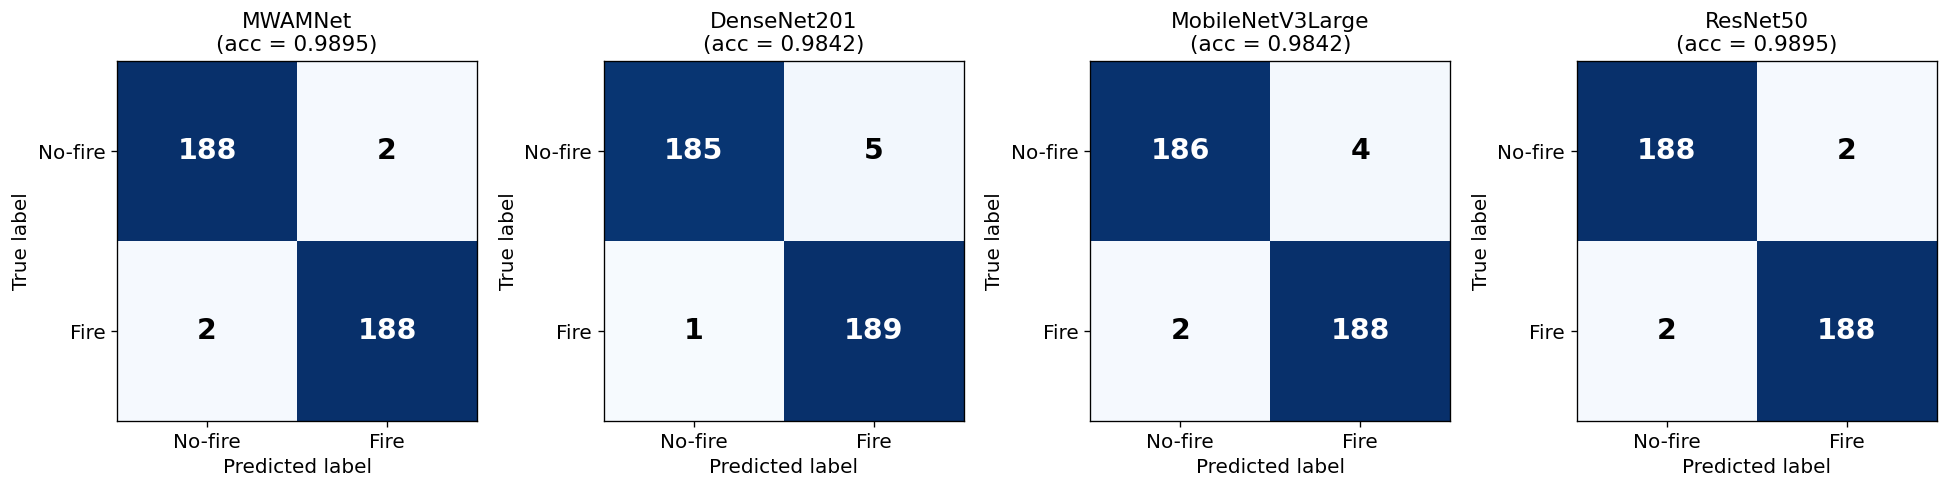

MWAMNet             nofire[ 188,   2]  fire[   2, 188]
DenseNet201         nofire[ 185,   5]  fire[   1, 189]
MobileNetV3Large    nofire[ 186,   4]  fire[   2, 188]
ResNet50            nofire[ 188,   2]  fire[   2, 188]
VGG16               nofire[ 185,   5]  fire[   3, 187]
InceptionV3         nofire[ 185,   5]  fire[   1, 189]
   backed up 2 file(s) to Drive


In [ ]:
#@title 8 · Confusion matrices at 300 dpi
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12, "font.family": "DejaVu Sans",
                     "savefig.dpi": 300, "figure.dpi": 120})

show = ["MWAMNet", "DenseNet201", "MobileNetV3Large", "ResNet50"]
fig, axes = plt.subplots(1, len(show), figsize=(4.1 * len(show), 4.1))
for ax, m in zip(np.atleast_1d(axes), show):
    cm = confusion_matrix(y_te, REP[m])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=17,
                    fontweight="bold",
                    color="white" if cm[i, j] > cm.max() * .55 else "black")
    ax.set_xticks([0, 1], ["No-fire", "Fire"])
    ax.set_yticks([0, 1], ["No-fire", "Fire"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("%s\n(acc = %.4f)" % (m, (REP[m] == y_te).mean()), fontsize=13)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(OUT, "figures", "confusion_matrices.%s" % ext),
                bbox_inches="tight")
plt.show()

for m in MODELS:
    tn, fp, fn, tp = confusion_matrix(y_te, REP[m]).ravel()
    print("%-18s  nofire[%4d,%4d]  fire[%4d,%4d]" % (m, tn, fp, fn, tp))
backup()

In [ ]:
#@title 9 · Ablation
ABLATIONS = [
    ("MWAMNet (full model)",          dict(backbones=["DenseNet201","MobileNetV3Large"])),
    ("DenseNet201 branch only",       dict(backbones=["DenseNet201"])),
    ("MobileNetV3Large branch only",  dict(backbones=["MobileNetV3Large"])),
    ("- data augmentation",           dict(backbones=["DenseNet201","MobileNetV3Large"], augment=False)),
    ("- dropout and L2",              dict(backbones=["DenseNet201","MobileNetV3Large"], drop=0.0, l2v=0.0)),
    ("- cosine decay (constant LR)",  dict(backbones=["DenseNet201","MobileNetV3Large"], cosine=False)),
    ("smaller head (512, 256)",       dict(backbones=["DenseNet201","MobileNetV3Large"], units=(512,256))),
]

rows, full = [], None
for label, kw0 in ABLATIONS:
    kw = dict(kw0); bbs = kw.pop("backbones")
    a = []
    for s in range(3):
        p, m = run(bbs, seed=CFG["SEED"] + s, **kw)
        a.append(accuracy_score(y_te, (p > .5).astype(int)))
    a = np.array(a)
    if full is None:
        full = a.mean()
    rows.append(dict(Configuration=label,
                     Accuracy="%.4f ± %.4f" % (a.mean(), a.std(ddof=1)),
                     Delta="%+.4f" % (a.mean() - full),
                     Head_params=m.count_params()))
    print("%-32s %.4f ± %.4f   (%+.4f)" % (label, a.mean(), a.std(ddof=1), a.mean()-full))

A = pd.DataFrame(rows)
A.to_csv(os.path.join(OUT, "results", "ablation.csv"), index=False)
display(A)
print("\nLaTeX:\n")
print(A.rename(columns={"Head_params": "Head params"}).to_latex(
      index=False, escape=False, float_format="%.4f",
      caption="Ablation study on the held-out test set (n=380), "
              "mean $\\pm$ SD over 3 seeds.",
      label="tab:ablation"))
backup()

MWAMNet (full model)             0.9868 ± 0.0053   (+0.0000)
DenseNet201 branch only          0.9877 ± 0.0030   (+0.0009)
MobileNetV3Large branch only     0.9754 ± 0.0106   (-0.0114)
- data augmentation              0.9851 ± 0.0040   (-0.0018)
- dropout and L2                 0.9851 ± 0.0015   (-0.0018)
- cosine decay (constant LR)     0.9868 ± 0.0026   (-0.0000)
smaller head (512, 256)          0.9860 ± 0.0055   (-0.0009)


,Configuration,Accuracy,Delta,Head_params
0,MWAMNet (full model),0.9868 ± 0.0053,+0.0000,3493121
1,DenseNet201 branch only,0.9877 ± 0.0030,+0.0009,2506241
2,MobileNetV3Large branch only,0.9754 ± 0.0106,-0.0114,1519361
3,- data augmentation,0.9851 ± 0.0040,-0.0018,3493121
4,- dropout and L2,0.9851 ± 0.0015,-0.0018,3493121
5,- cosine decay (constant LR),0.9868 ± 0.0026,-0.0000,3493121
6,"smaller head (512, 256)",0.9860 ± 0.0055,-0.0009,1621249



LaTeX:

\begin{table}
\caption{Ablation study on the held-out test set (n=380), mean $\pm$ SD over 3 seeds.}
\label{tab:ablation}
\begin{tabular}{lllr}
\toprule
Configuration & Accuracy & Delta & Head params \\
\midrule
MWAMNet (full model) & 0.9868 ± 0.0053 & +0.0000 & 3493121 \\
DenseNet201 branch only & 0.9877 ± 0.0030 & +0.0009 & 2506241 \\
MobileNetV3Large branch only & 0.9754 ± 0.0106 & -0.0114 & 1519361 \\
- data augmentation & 0.9851 ± 0.0040 & -0.0018 & 3493121 \\
- dropout and L2 & 0.9851 ± 0.0015 & -0.0018 & 3493121 \\
- cosine decay (constant LR) & 0.9868 ± 0.0026 & -0.0000 & 3493121 \\
smaller head (512, 256) & 0.9860 ± 0.0055 & -0.0009 & 1621249 \\
\bottomrule
\end{tabular}
\end{table}

   backed up 1 file(s) to Drive


In [ ]:
#@title 10 · Summary
backup()
print("Working folder:", WORK)
print("Drive copy    :", MIRROR or "NONE - download the files below before you close Colab")
for sub in ("results", "figures"):
    for f in sorted(os.listdir(os.path.join(OUT, sub))):
        print("  %s/%s" % (sub, f))
print("\nHeld-out test set: %d images (%d no-fire, %d fire)"
      % (len(y_te), (y_te == 0).sum(), (y_te == 1).sum()))
print("Best model:", T.iloc[0]["Model"], "  accuracy:", T.iloc[0]["Accuracy"],
      " CI:", T.iloc[0]["CI95"])

   backed up 0 file(s) to Drive
Working folder: /content/MWAMNet_revision
Drive copy    : /content/drive/MyDrive/MWAMNet_revision
  results/DenseNet201_probs.npy
  results/InceptionV3_probs.npy
  results/MWAMNet_probs.npy
  results/MobileNetV3Large_probs.npy
  results/ResNet50_probs.npy
  results/VGG16_probs.npy
  results/ablation.csv
  results/mcnemar.csv
  results/per_seed.csv
  results/representative_preds.npy
  results/split_manifest.json
  results/table2.csv
  results/y_test.npy
  results/y_train_aug.npy
  results/y_val.npy
  figures/confusion_matrices.pdf
  figures/confusion_matrices.png

Held-out test set: 380 images (190 no-fire, 190 fire)
Best model: MWAMNet   accuracy: 0.9895  CI: [0.9733, 0.9959]
